---
title: DFT, Periodogram and RSS
---

### Discrete Fourier Transform

For a dataset $y_0, \dots, y_{n-1}$, its DFT is $b_0, b_1, \dots, b_{n-1}$ where
\begin{equation*}
   b_j = \sum_{t=0}^{n-1} y_t \exp \left(-\frac{2 \pi i j t}{n} \right).
\end{equation*}
for $j = 0, 1, \dots, n-1$. In other words, $b_j$ is a complex number with real part $\sum_t y_t \cos(2 \pi (j/n) t)$ and imaginary part $-\sum_t y_t \sin(2 \pi (j/n) t)$. 

In [65]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [66]:
help(np.fft.fft)

Help on method descriptor fft in module numpy.fft:

fft(a, n=None, axis=-1, norm=None, out=None)
    Compute the one-dimensional discrete Fourier Transform.

    This function computes the one-dimensional *n*-point discrete Fourier
    Transform (DFT) with the efficient Fast Fourier Transform (FFT)
    algorithm [CT]_.

    Parameters
    ----------
    a : array_like
        Input array, can be complex.
    n : int, optional
        Length of the transformed axis of the output.
        If `n` is smaller than the length of the input, the input is cropped.
        If it is larger, the input is padded with zeros.  If `n` is not given,
        the length of the input along the axis specified by `axis` is used.
    axis : int, optional
        Axis over which to compute the FFT.  If not given, the last axis is
        used.
    norm : {"backward", "ortho", "forward"}, optional
        Normalization mode (see `numpy.fft`). Default is "backward".
        Indicates which direction of the forw

In [69]:
y = np.array([1, -5, 3, 10, -5, 1, 6])
dft_y = np.fft.fft(y)
print(dft_y)
b0 = np.sum(y)
print(b0)
n = len(y)
#Here is the formula for calculating the real and imaginary parts of b2:
f = 3/n
cosvec = np.cos(2 * np.pi * f * np.arange(n))
sinvec = np.sin(2 * np.pi * f * np.arange(n))
b_cos = np.sum(y * cosvec)
b_sin = np.sum(y * sinvec)
print(b_cos, b_sin) #the real part of DFT is b_cos and the imaginary part is -b_sin (note the negative sign for the imaginary part)

[11.         +0.j         -3.77143827 +0.1420344j
  0.2910526 +23.31944675j  1.48038567 -8.28753459j
  1.48038567 +8.28753459j  0.2910526 -23.31944675j
 -3.77143827 -0.1420344j ]
11
1.4803856697509472 8.287534587498158


### RSS calculation at Fourier Frequencies using the DFT

In the last lecture, we looked at the sunspots dataset, and attempted to fit the simple sinusoidal model: 
\begin{equation*}
  y_t = \beta_0 + \beta_1 \cos(2 \pi f t) + \beta_2 \sin(2 \pi f t) + \epsilon_t
\end{equation*}
with $\epsilon_t$ being i.i.d $N(0, \sigma^2)$. The important parameter in this model is $f$. To estimate $f$, our strategy was to minimize $RSS(f)$, which we computed for all values of $f$ in a grid taken over the range $[0, 0.5]$. 

In [70]:
#annual sunspots dataset:
sunspots = pd.read_csv('SN_y_tot_V2.0_17Sept2026.csv', header = None, sep = ';')
print(sunspots.head())
sunspots.columns = ['year', 'sunspotsmean', 'sunspotssd', 'sunspotsnobs', 'isdefinitive']
print(sunspots.head(10))

        0     1    2  3  4
0  1700.5   8.3 -1.0 -1  1
1  1701.5  18.3 -1.0 -1  1
2  1702.5  26.7 -1.0 -1  1
3  1703.5  38.3 -1.0 -1  1
4  1704.5  60.0 -1.0 -1  1
     year  sunspotsmean  sunspotssd  sunspotsnobs  isdefinitive
0  1700.5           8.3        -1.0            -1             1
1  1701.5          18.3        -1.0            -1             1
2  1702.5          26.7        -1.0            -1             1
3  1703.5          38.3        -1.0            -1             1
4  1704.5          60.0        -1.0            -1             1
5  1705.5          96.7        -1.0            -1             1
6  1706.5          48.3        -1.0            -1             1
7  1707.5          33.3        -1.0            -1             1
8  1708.5          16.7        -1.0            -1             1
9  1709.5          13.3        -1.0            -1             1


0     8.3
1    18.3
2    26.7
3    38.3
4    60.0
Name: sunspotsmean, dtype: float64


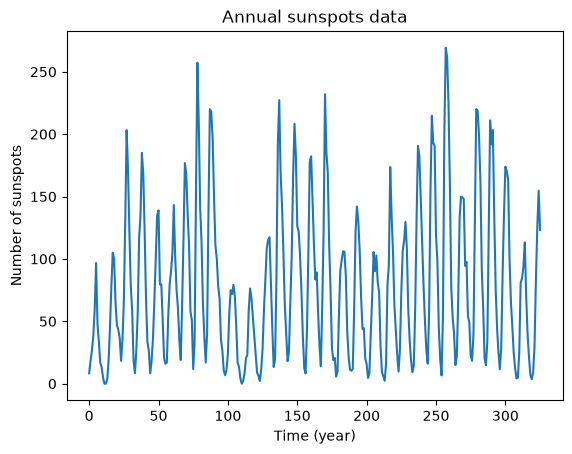

In [71]:
y = sunspots['sunspotsmean']
n = len(y)
print(y.head())
plt.plot(y)
plt.xlabel('Time (year)')
plt.ylabel('Number of sunspots')
plt.title('Annual sunspots data')
plt.show()

The RSS function that we used is given by: 

In [72]:
def rss(f):
    x = np.arange(1, n+1)
    if f == 0.5:
        # Exact cosine values; omit the mathematically zero sine column.
        X = np.column_stack([np.ones(n), (-1.0) ** x])
    else:
        xcos = np.cos(2 * np.pi * f * x)
        xsin = np.sin(2 * np.pi * f * x)
        X = np.column_stack([np.ones(n), xcos, xsin])
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    return rss

The following is the code for computing RSS over a grid of values of $f$. 

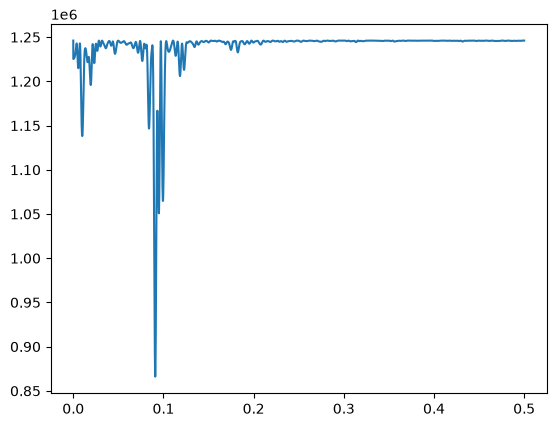

In [73]:
num_f_vals = 10000 #this is the number of different values of f we will try
allfvals = np.linspace(0, 0.5, num_f_vals)
rssvals = np.array([rss(f) for f in allfvals])
plt.plot(allfvals, rssvals)
plt.show()

Below we compute the estimate of $f$ by minimizing $RSS(f)$ over our grid. 

In [74]:
fhat = allfvals[np.argmin(rssvals)]
print(fhat)
print(1/fhat) #this is the estimated periodicity in years

0.09090909090909091
11.0


Now we repeat this exercise of estimation of $f$. But we restrict to Fourier frequencies (as opposed to a possibly finer grid of frequencies in $[0, 0.5]$), and then we use the connection between RSS at Fourier frequencies and the DFT, to compute RSS.

The formula connecting RSS and the DFT is the following. Suppose $f = j/n$ is a Fourier frequency lying strictly between 0 and $0.5$. Then: 
\begin{equation*}
   RSS(j/n) = \sum_t (y_t - \bar{y})^2 - 2 \frac{|b_j|^2}{n}
\end{equation*}
where $b_j$ is the $j$th DFT term given by 
\begin{equation*}
   b_j := \sum_{t=0}^{n-1} y_t \exp \left(-\frac{2 \pi i j t}{n} \right). 
\end{equation*}
The quantity $|b_j|^2/n$ is denoted by $I(j/n)$ and is called the periodogram: 
\begin{align*}
   I(j/n) := \frac{|b_j|^2}{n} ~~ \text{ for } 0 < \frac{j}{n} < 1/2. 
\end{align*}
When $j/n = 1/2$ (this will only arise when $n$ is even), we have
\begin{align*}
   RSS(1/2) = RSS(j/n) = \sum_t (y_t - \bar{y})^2 - \frac{|b_{n/2}|^2}{n}
\end{align*}
Note that there is no factor of 2 in front of the term $|b_j|^2/n$ above. 

Below we illustrate computation of $RSS(f)$ for Fourier frequencies in the range $(0, 1/2)$ using the above formula. 

In [75]:
#First form the set of Fourier frequencies
print(n)
#If n is odd, the Fourier frequencies in (0, 0.5) are 1/n, 2/n, ..., (n-1)/(2n)
#If n is even, the Fourier frequencies in (0, 0.5) are 1/n, 2/n, ..., (n/2-1)/n, n/2n = 0.5
m = n // 2
fourier_freq = (np.arange(1, m+1))/(n)
print(fourier_freq)

326
[0.00306748 0.00613497 0.00920245 0.01226994 0.01533742 0.01840491
 0.02147239 0.02453988 0.02760736 0.03067485 0.03374233 0.03680982
 0.0398773  0.04294479 0.04601227 0.04907975 0.05214724 0.05521472
 0.05828221 0.06134969 0.06441718 0.06748466 0.07055215 0.07361963
 0.07668712 0.0797546  0.08282209 0.08588957 0.08895706 0.09202454
 0.09509202 0.09815951 0.10122699 0.10429448 0.10736196 0.11042945
 0.11349693 0.11656442 0.1196319  0.12269939 0.12576687 0.12883436
 0.13190184 0.13496933 0.13803681 0.14110429 0.14417178 0.14723926
 0.15030675 0.15337423 0.15644172 0.1595092  0.16257669 0.16564417
 0.16871166 0.17177914 0.17484663 0.17791411 0.1809816  0.18404908
 0.18711656 0.19018405 0.19325153 0.19631902 0.1993865  0.20245399
 0.20552147 0.20858896 0.21165644 0.21472393 0.21779141 0.2208589
 0.22392638 0.22699387 0.23006135 0.23312883 0.23619632 0.2392638
 0.24233129 0.24539877 0.24846626 0.25153374 0.25460123 0.25766871
 0.2607362  0.26380368 0.26687117 0.26993865 0.27300613 0.27

There is an inbuilt function in np for listing out all Fourier frequencies. This is the **np.fft.fftfreq(n)**. This gives all the frequencies $f$ for which $nf$ is an integer and for which $f \in [-0.5, 0.5)$ (there will be exactly $n$ of these frequencies in both cases where $n$ is odd or even). We will not work with negative frequencies so we will not use this function. 


In [76]:
help(np.fft.fftfreq)

Help on function fftfreq in module numpy.fft:

fftfreq(n, d=1.0, device=None)
    Return the Discrete Fourier Transform sample frequencies.

    The returned float array `f` contains the frequency bin centers in cycles
    per unit of the sample spacing (with zero at the start).  For instance, if
    the sample spacing is in seconds, then the frequency unit is cycles/second.

    Given a window length `n` and a sample spacing `d`::

      f = [0, 1, ...,   n/2-1,     -n/2, ..., -1] / (d*n)   if n is even
      f = [0, 1, ..., (n-1)/2, -(n-1)/2, ..., -1] / (d*n)   if n is odd

    Parameters
    ----------
    n : int
        Window length.
    d : scalar, optional
        Sample spacing (inverse of the sampling rate). Defaults to 1.
    device : str, optional
        The device on which to place the created array. Default: ``None``.
        For Array-API interoperability only, so must be ``"cpu"`` if passed.

        .. versionadded:: 2.0.0

    Returns
    -------
    f : ndarray
    

Below we compute the $RSS(f)$ for Fourier frequencies $f$ using our previous function rss. 

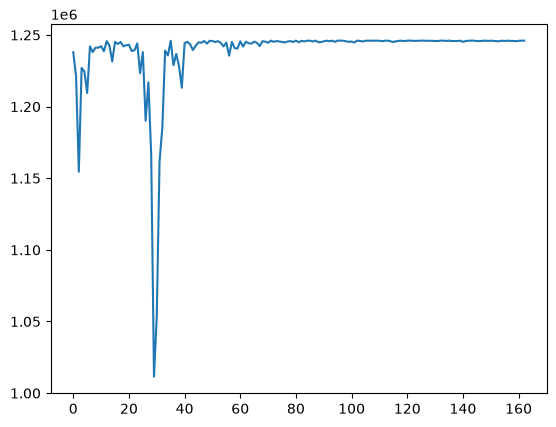

In [77]:
#let us compute rss(f) for f in the Fourier grid
rss_fourier = np.array([rss(f) for f in fourier_freq])
plt.plot(rss_fourier)
plt.show()

Next we compute the same thing using the DFT (calculated via the FFT), and its connection to the RSS. 

In [78]:
#Now we shall compute it using the FFT:
fft_y = np.fft.fft(y)
pgram_y = np.abs(fft_y[1:m + 1]) ** 2/n #we are picking up the entries 1,..,m of fft_y, then taking absolute values and squares, and then dividing by n
var_y = np.sum((y - np.mean(y)) ** 2) 
rss_fft = var_y - 2 * pgram_y
#if n is even, we need to 
rss_fft[-1] = var_y - pgram_y[-1] #this is the last entry of rss_fft, which corresponds to the frequency 0.5

Below, we plot the two different calculations of $RSS(f)$ (for $f$ ranging among Fourier frequencies) on the same figure. We want to demonstrate the two calculations lead to identical answers. 

In [79]:
#Plotting rss_fourier and rss_fft as two columns of an array to see if they are the same:
print(np.column_stack([rss_fourier, rss_fft]))


[[1237952.4082683  1237952.4082683 ]
 [1221333.3339125  1221333.3339125 ]
 [1154547.04941306 1154547.04941306]
 [1227024.71128038 1227024.71128038]
 [1224422.22938119 1224422.22938119]
 [1209492.754961   1209492.754961  ]
 [1242036.15647255 1242036.15647255]
 [1238070.09169468 1238070.09169468]
 [1241180.91266546 1241180.91266546]
 [1241110.03441001 1241110.03441001]
 [1242209.91485975 1242209.91485975]
 [1238644.61669992 1238644.61669992]
 [1245691.60730747 1245691.60730747]
 [1242574.3977063  1242574.3977063 ]
 [1231575.71705047 1231575.71705047]
 [1245226.19681308 1245226.19681308]
 [1243696.00147683 1243696.00147683]
 [1245079.94859374 1245079.94859374]
 [1242124.75063445 1242124.75063445]
 [1242810.96903545 1242810.96903545]
 [1243128.67110061 1243128.67110061]
 [1238835.4846556  1238835.4846556 ]
 [1239362.63445208 1239362.63445208]
 [1244094.81617267 1244094.81617267]
 [1223299.09559811 1223299.09559811]
 [1238027.88351783 1238027.88351783]
 [1190143.55121249 1190143.55121249]
 

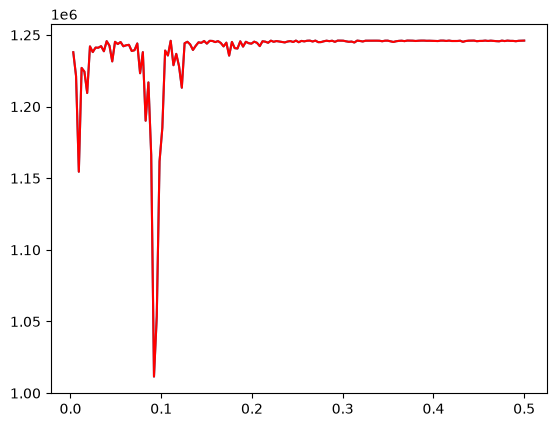

In [80]:
plt.plot(fourier_freq, rss_fourier)
plt.plot(fourier_freq, rss_fft, color = 'red')

The first method of directly computing $RSS(f)$ is actually quite computationally expensive. The second method (which leverages the connection to the Discrete Fourier Transform) is much more efficient because of the FFT algorithm. We shall illustrate this below using a very large audio dataset. 

## An Audio Dataset

The "Hear Piano Note - Middle C.mp3$ is an audio file consisting of about 14 seconds. It contains the sound of the Middle C note in the piano. The python library "Librosa" will be used for loading the audio file (see https://librosa.org/doc/latest/index.html for instructions on installing librosa, and tutorials etc.)

In [107]:
import librosa
yorig,sr=librosa.load("Hear Piano Note - Middle C.mp3")
sig_noise = 0
y = yorig + sig_noise*np.random.randn(len(yorig)) #adding noise to the audio signal
n = len(y)
print(n)
print(sr)
print(n/sr)

301272
22050
13.66312925170068


In [108]:
from IPython.display import Audio, display
display(Audio(y, rate=sr))

Each second of the audio file is captured in $sr$ (which stands for "sampling rate" and whose default value is 22050) many datapoints. In other words, the unit of time for this dataset is $1/sr$. The total number of datapoints equals $sr$ muliplied by the number of seconds of the audio file. Clearly this is a time series dataset of a large size. The data (sound waveform) is plotted below.

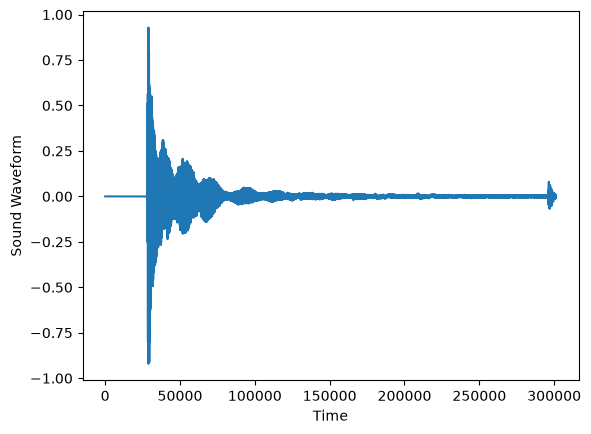

In [109]:
plt.plot(y)
plt.xlabel("Time")
plt.ylabel("Sound Waveform")
plt.show()

The full plot of the data is not very revealing as the data size is very long. But if we restrict to a smaller portion of the dataset, we can visualize the cyclical behavior more easily. 

Text(0, 0.5, 'Sound waveform')

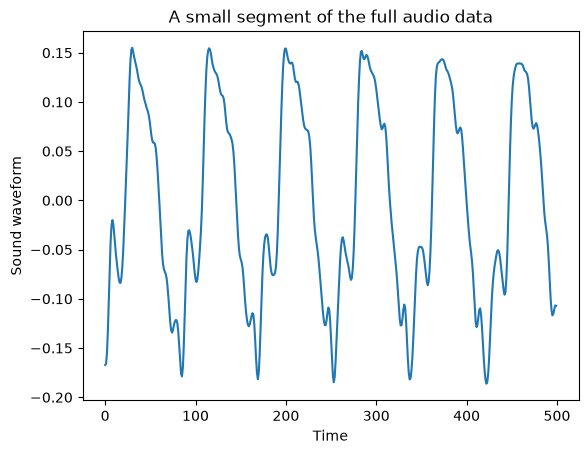

In [101]:
y_smallpart = y[50000:(50000 + 500)]
plt.plot(y_smallpart)
plt.xlabel('Time')
plt.title('A small segment of the full audio data')
plt.ylabel('Sound waveform')

Let us attempt to fit our simple sinusoidal model $y_t = \beta_0 + \beta_1 \cos(2 \pi f t) + \beta_2 \sin (2 \pi f t) + \epsilon_t$ to this dataset. The key is to calculate $RSS(f)$. If we try our first method of direct computation of $RSS(f)$ for each value of $f$ in a grid, it will be too slow because of the large size $n$. 

In [89]:
ngrid = 10000
allfvals = np.linspace(0, 0.5, ngrid)
rssvals = np.array([rss(f) for f in allfvals])
plt.plot(allfvals, rssvals)

KeyboardInterrupt: 

The above piece of code is taking too long to run (it will take about 4-5 minutes). If we abandon it, and instead use the FFT-Periodogram connection to compute $RSS(f)$, the code runs way faster and gives the values of $RSS(f)$ on the Fourier grid which contains many more points than $10000$. 

In [110]:
fft_y = np.fft.fft(y)
m = (n // 2) - 1
fourier_freq = (np.arange(1, m+1))/(n)
pgram_y = (np.abs(fft_y[1:(m+1)]) ** 2)/n
var_y = np.sum((y - np.mean(y)) ** 2)
rss_fft = var_y - 2 * pgram_y

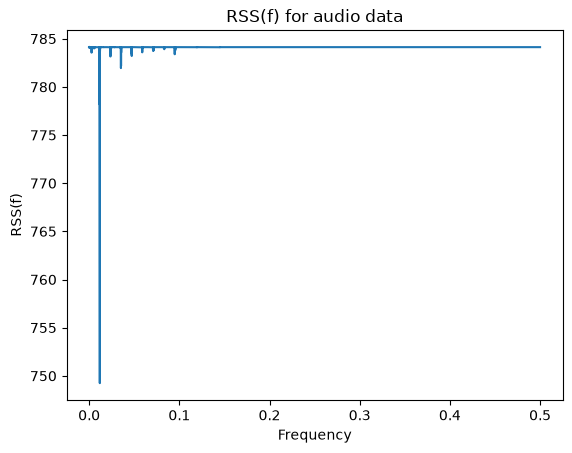

In [111]:
plt.plot(fourier_freq, rss_fft)
plt.title('RSS(f) for audio data')
plt.xlabel('Frequency')
plt.ylabel('RSS(f)')
plt.show()

Let us compute the frequency which minimizes $RSS(f)$. 

In [112]:
fourier_freq = (np.arange(1, m+1))/(n)
best_freq = fourier_freq[np.argmin(rss_fft)]
print(best_freq)

0.011799968135107145


The frequency corresponding to the middle $C$ note on the piano is approximately 261.63 Hz (see e.g., https://en.wikipedia.org/wiki/C_(musical_note)). How does 261.63 Hz relate to the periodogram maximizing frequency (or, equivalently, RSS minimizing frequency) above? The connection between the two is obtained by multiplication by the sampling rate $sr$. The sinusoid $\cos (2 \pi f t)$ completes $f$ cycles in unit time. In this dataset, one unit of time is given by $1/sr$ seconds. So this sinusoid completes $f \times sr$ cycles in one sec which means that, in Hertz (which is the number of cycles per second), the frequency $f$ corresponds to $f \times sr$.  

In [113]:
print(best_freq * sr) #this is quite close to 261.63 Hz. 

260.18929737911253


For this dataset, the single sinusoid model is actually not a very good model. To see this, consider the audio file generated by the fitted values. Play this audio and compare it to the actual dataset. We shall look at better models for this data later. 

In [114]:
from IPython.display import Audio, display

t = np.arange(1, len(y) + 1)

X = np.column_stack([
    np.ones(len(y)),
    np.cos(2 * np.pi * best_freq * t),
    np.sin(2 * np.pi * best_freq * t)
])

md = sm.OLS(y, X).fit()
fitted_sinusoid = md.fittedvalues

display(Audio(fitted_sinusoid, rate=sr))
display(Audio(y, rate=sr))
display(Audio(yorig, rate=sr))

Compare this sound to the original sound file. 